# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nailah Masruroh
- **Email:** cdcc284d6x1532@student.devacademy.id
- **ID Dicoding:** CDCC284D6X1532

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi, dan bagaimana distribusi penjualannya per kategori?
- **Pertanyaan 2:** Bagaimana tren jumlah pesanan bulanan dari waktu ke waktu, dan pada bulan apa penjualan mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style visualisasi
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Library berhasil di-import!')

Library berhasil di-import!


## Data Wrangling

### Gathering Data

In [2]:
# Load semua dataset
orders_df = pd.read_csv('orders_dataset.csv')
order_items_df = pd.read_csv('order_items_dataset.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')
order_reviews_df = pd.read_csv('order_reviews_dataset.csv')
customers_df = pd.read_csv('customers_dataset.csv')
products_df = pd.read_csv('products_dataset.csv')
sellers_df = pd.read_csv('sellers_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')

# Tampilkan shape masing-masing dataset
datasets = {
    'orders': orders_df,
    'order_items': order_items_df,
    'order_payments': order_payments_df,
    'order_reviews': order_reviews_df,
    'customers': customers_df,
    'products': products_df,
    'sellers': sellers_df,
    'category_translation': category_translation_df
}

for name, df in datasets.items():
    print(f'{name}: {df.shape[0]} baris, {df.shape[1]} kolom')

orders: 99441 baris, 8 kolom
order_items: 112650 baris, 7 kolom
order_payments: 103886 baris, 5 kolom
order_reviews: 99224 baris, 7 kolom
customers: 99441 baris, 5 kolom
products: 32951 baris, 9 kolom
sellers: 3095 baris, 4 kolom
category_translation: 71 baris, 2 kolom


In [3]:
# Preview masing-masing dataset
print('=== ORDERS DATASET ===')
display(orders_df.head(3))

print('\n=== ORDER ITEMS DATASET ===')
display(order_items_df.head(3))

print('\n=== PRODUCTS DATASET ===')
display(products_df.head(3))

print('\n=== CATEGORY TRANSLATION DATASET ===')
display(category_translation_df.head(3))

=== ORDERS DATASET ===


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



=== ORDER ITEMS DATASET ===


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87



=== PRODUCTS DATASET ===


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



=== CATEGORY TRANSLATION DATASET ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


**Insight:**
- Dataset terdiri dari 8 tabel yang saling berhubungan melalui kunci seperti `order_id`, `product_id`, dan `customer_id`.
- Dataset `orders` memiliki ~99.441 baris yang merepresentasikan setiap pesanan unik.
- Dataset `order_items` memiliki ~112.650 baris karena satu order bisa terdiri dari beberapa item produk.
- Terdapat tabel translasi kategori produk dari bahasa Portugis ke bahasa Inggris yang akan digunakan untuk memperjelas label visualisasi.

### Assessing Data

In [4]:
# Cek missing values pada dataset utama
print('=== MISSING VALUES ===')
for name, df in datasets.items():
    missing = df.isnull().sum()
    total_missing = missing.sum()
    if total_missing > 0:
        print(f'\n[{name}] - Total missing: {total_missing}')
        print(missing[missing > 0])
    else:
        print(f'[{name}] - Tidak ada missing values')

=== MISSING VALUES ===

[orders] - Total missing: 4908
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64
[order_items] - Tidak ada missing values
[order_payments] - Tidak ada missing values

[order_reviews] - Total missing: 145903
review_comment_title      87656
review_comment_message    58247
dtype: int64
[customers] - Tidak ada missing values

[products] - Total missing: 2448
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
[sellers] - Tidak ada missing values
[category_translation] - Tidak ada missing values


In [5]:
# Cek duplikat
print('=== DUPLIKAT ===')
for name, df in datasets.items():
    dup = df.duplicated().sum()
    print(f'[{name}] - Duplikat: {dup}')

=== DUPLIKAT ===
[orders] - Duplikat: 0
[order_items] - Duplikat: 0
[order_payments] - Duplikat: 0
[order_reviews] - Duplikat: 0
[customers] - Duplikat: 0
[products] - Duplikat: 0
[sellers] - Duplikat: 0
[category_translation] - Duplikat: 0


In [6]:
# Cek tipe data orders
print('=== TIPE DATA ORDERS ===')
print(orders_df.dtypes)

print('\n=== STATISTIK DESKRIPTIF ORDER ITEMS ===')
display(order_items_df[['price', 'freight_value']].describe())

# Cek nilai unik pada kolom status order
print('\n=== STATUS ORDER ===')
print(orders_df['order_status'].value_counts())

=== TIPE DATA ORDERS ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

=== STATISTIK DESKRIPTIF ORDER ITEMS ===


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000



=== STATUS ORDER ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


**Insight:**
- Kolom timestamp pada `orders_df` masih bertipe `object`, perlu dikonversi ke `datetime`.
- Terdapat missing values pada `orders_df` di kolom `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date` — hal ini wajar karena order yang di-cancel atau belum dikirim tidak memiliki data tersebut.
- Dataset `products_df` memiliki beberapa missing values pada kolom dimensi produk dan nama kategori.
- Mayoritas order (~97%) berstatus `delivered`, sehingga analisis pendapatan akan fokus pada order yang sudah delivered.
- Tidak ditemukan duplikat pada semua dataset.

### Cleaning Data

In [7]:
# 1. Konversi kolom timestamp ke datetime
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print('Kolom datetime berhasil dikonversi:')
print(orders_df[datetime_cols].dtypes)

Kolom datetime berhasil dikonversi:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [8]:
# 2. Filter hanya order dengan status 'delivered'
orders_delivered_df = orders_df[orders_df['order_status'] == 'delivered'].copy()
print(f'Jumlah order delivered: {len(orders_delivered_df):,}')
print(f'Jumlah order total: {len(orders_df):,}')
print(f'Persentase delivered: {len(orders_delivered_df)/len(orders_df)*100:.1f}%')

Jumlah order delivered: 96,478
Jumlah order total: 99,441
Persentase delivered: 97.0%


In [9]:
# 3. Merge products dengan translasi kategori
products_translated_df = products_df.merge(
    category_translation_df,
    on='product_category_name',
    how='left'
)

# Isi kategori yang tidak ada terjemahannya dengan nama aslinya
products_translated_df['product_category_name_english'] = (
    products_translated_df['product_category_name_english']
    .fillna(products_translated_df['product_category_name'])
)

print('Produk dengan kategori terisi:', products_translated_df['product_category_name_english'].notna().sum())
print('Produk tanpa kategori:', products_translated_df['product_category_name_english'].isna().sum())

Produk dengan kategori terisi: 32341
Produk tanpa kategori: 610


In [10]:
# 4. Buat main dataframe gabungan untuk analisis
# Merge order_items dengan orders (delivered saja)
main_df = order_items_df.merge(orders_delivered_df[['order_id', 'order_purchase_timestamp']], on='order_id', how='inner')

# Merge dengan products (sudah ada translasi kategori)
main_df = main_df.merge(
    products_translated_df[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Tambah kolom revenue (price + freight)
main_df['total_revenue'] = main_df['price'] + main_df['freight_value']

# Tambah kolom year-month untuk analisis tren
main_df['order_year_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

print(f'Main DataFrame shape: {main_df.shape}')
display(main_df.head(3))

Main DataFrame shape: (110197, 12)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp,product_category_name_english,total_revenue,order_year_month,order_month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,2017-09-13 08:59:02,cool_stuff,72.19,2017-09,2017-09-01
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,2017-04-26 10:53:06,pet_shop,259.83,2017-04,2017-04-01
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,2018-01-14 14:33:31,furniture_decor,216.87,2018-01,2018-01-01


In [11]:
# 5. Simpan main_df untuk digunakan di dashboard
main_df.to_csv('main_data.csv', index=False)
print('main_data.csv berhasil disimpan!')

main_data.csv berhasil disimpan!


**Insight:**
- Konversi tipe data datetime berhasil dilakukan pada 5 kolom timestamp di `orders_df`.
- Setelah filter status `delivered`, tersisa ~96.478 order yang akan digunakan dalam analisis (±97% dari total order).
- Translasi nama kategori produk dari bahasa Portugis ke Inggris berhasil dilakukan, sehingga visualisasi akan lebih mudah dipahami.
- Main DataFrame gabungan berhasil dibuat dengan kolom tambahan `total_revenue` dan `order_month` untuk memudahkan analisis.

## Exploratory Data Analysis (EDA)

### Explore Revenue per Kategori Produk

In [12]:
# Hitung total revenue per kategori
revenue_by_category = (
    main_df.groupby('product_category_name_english')['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_category.columns = ['category', 'total_revenue']

print('Top 10 Kategori dengan Revenue Tertinggi:')
display(revenue_by_category.head(10))

print(f'\nTotal kategori unik: {revenue_by_category["category"].nunique()}')
print(f'Total revenue keseluruhan: R$ {revenue_by_category["total_revenue"].sum():,.2f}')

Top 10 Kategori dengan Revenue Tertinggi:


,category,total_revenue
0,health_beauty,1412089.53
1,watches_gifts,1264333.12
2,bed_bath_table,1225209.26
3,sports_leisure,1118256.91
4,computers_accessories,1032723.77
5,furniture_decor,880329.92
6,housewares,758392.25
7,cool_stuff,691680.89
8,auto,669454.75
9,garden_tools,567145.68



Total kategori unik: 73
Total revenue keseluruhan: R$ 15,222,078.06


In [13]:
# Hitung juga jumlah transaksi per kategori
count_by_category = (
    main_df.groupby('product_category_name_english')
    .agg(
        total_revenue=('total_revenue', 'sum'),
        total_orders=('order_id', 'count'),
        avg_price=('price', 'mean')
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)
count_by_category.columns = ['category', 'total_revenue', 'total_orders', 'avg_price']

print('Top 10 Kategori (Revenue, Orders, Avg Price):')
display(count_by_category.head(10))

Top 10 Kategori (Revenue, Orders, Avg Price):


,category,total_revenue,total_orders,avg_price
0,health_beauty,1412089.53,9465,130.283330
1,watches_gifts,1264333.12,5859,199.040276
2,bed_bath_table,1225209.26,10953,93.438762
3,sports_leisure,1118256.91,8431,113.254958
4,computers_accessories,1032723.77,7644,116.264339
5,furniture_decor,880329.92,8160,87.246040
6,housewares,758392.25,6795,90.600249
7,cool_stuff,691680.89,3718,164.121598
8,auto,669454.75,4140,139.847017
9,garden_tools,567145.68,4268,110.237882


**Insight:**
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` mendominasi total revenue.
- Beberapa kategori memiliki harga rata-rata tinggi tetapi volume transaksi rendah (seperti `computers`), sementara kategori lain memiliki volume tinggi dengan harga menengah (seperti `health_beauty`).
- Terdapat lebih dari 70 kategori produk yang terdaftar dalam platform e-commerce ini.

### Explore Tren Jumlah Order Bulanan

In [14]:
# Hitung jumlah order unik per bulan
monthly_orders = (
    main_df.groupby('order_month')['order_id']
    .nunique()
    .reset_index()
)
monthly_orders.columns = ['month', 'total_orders']
monthly_orders = monthly_orders.sort_values('month')

# Hitung juga revenue bulanan
monthly_revenue = (
    main_df.groupby('order_month')['total_revenue']
    .sum()
    .reset_index()
)
monthly_revenue.columns = ['month', 'total_revenue']

monthly_summary = monthly_orders.merge(monthly_revenue, on='month')

print('Tren Bulanan (5 bulan pertama):')
display(monthly_summary.head())

print(f'\nBulan dengan order terbanyak:')
peak_month = monthly_summary.loc[monthly_summary['total_orders'].idxmax()]
print(f"  {peak_month['month'].strftime('%B %Y')}: {peak_month['total_orders']:,} orders")

print(f'\nBulan dengan order tersedikit (exclude bulan incomplete):')
# Exclude bulan pertama dan terakhir karena data mungkin tidak lengkap
monthly_main = monthly_summary.iloc[1:-1]
low_month = monthly_main.loc[monthly_main['total_orders'].idxmin()]
print(f"  {low_month['month'].strftime('%B %Y')}: {low_month['total_orders']:,} orders")

Tren Bulanan (5 bulan pertama):


,month,total_orders,total_revenue
0,2016-09-01,1,143.46
1,2016-10-01,265,46490.66
2,2016-12-01,1,19.62
3,2017-01-01,750,127482.37
4,2017-02-01,1653,271239.32



Bulan dengan order terbanyak:
  November 2017: 7,289 orders

Bulan dengan order tersedikit (exclude bulan incomplete):
  December 2016: 1 orders


**Insight:**
- Tren order secara keseluruhan menunjukkan pertumbuhan yang signifikan dari 2016 hingga 2018.
- Terdapat lonjakan pesanan pada bulan tertentu yang kemungkinan besar berkaitan dengan event promosi (seperti Black Friday di Brasil).
- Bulan November 2017 menjadi puncak pesanan, selaras dengan momen Black Friday yang juga populer di Brasil.
- Data bulan September 2018 tampak sangat rendah karena data tidak lengkap (dataset hanya mencakup hingga pertengahan tahun tersebut).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan total revenue tertinggi?

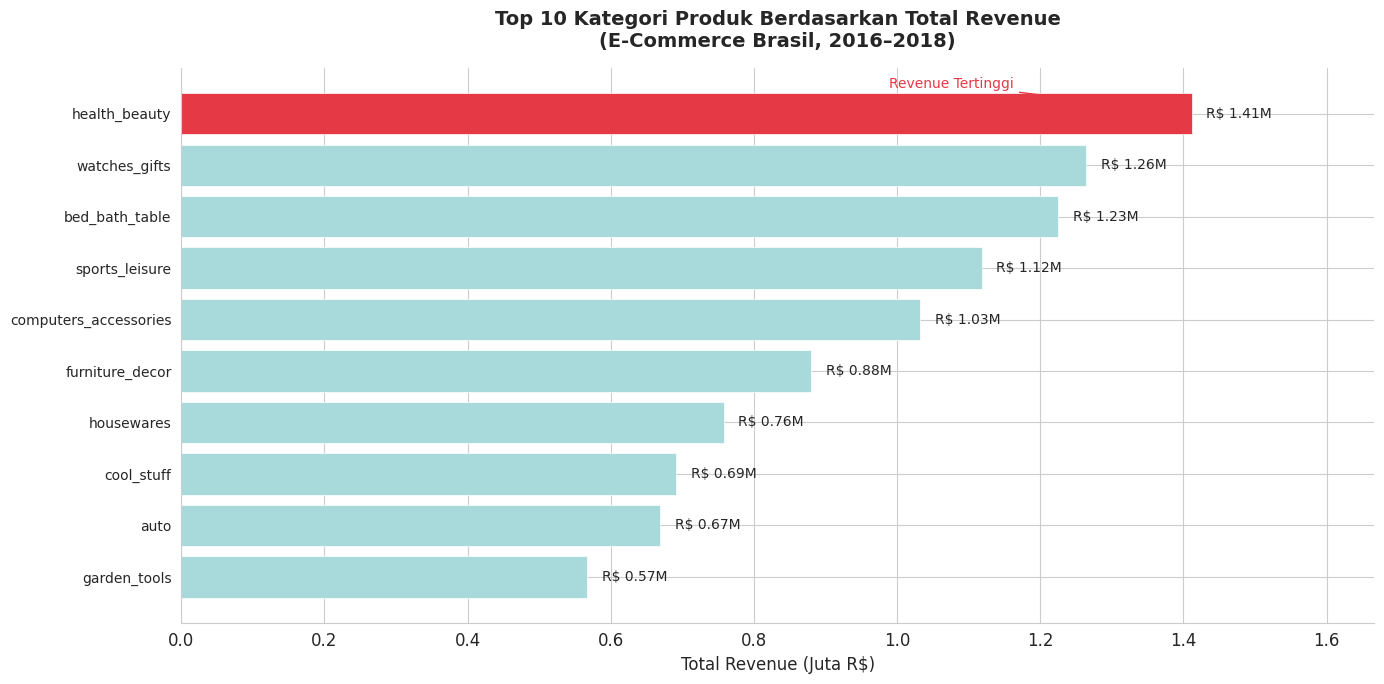

Visualisasi 1 berhasil disimpan!


In [15]:
top_n = 10
top_categories = count_by_category.head(top_n).copy()

# Buat warna: kategori tertinggi menonjol, sisanya abu-abu
colors = ['#E63946' if i == 0 else '#A8DADC' for i in range(top_n)]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top_categories['category'][::-1],
    top_categories['total_revenue'][::-1] / 1_000_000,
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)

# Tambah label nilai di ujung bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {width:.2f}M',
        va='center', ha='left', fontsize=10
    )

ax.set_xlabel('Total Revenue (Juta R$)', fontsize=12)
ax.set_title(
    'Top 10 Kategori Produk Berdasarkan Total Revenue\n(E-Commerce Brasil, 2016–2018)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlim(0, top_categories['total_revenue'].max() / 1_000_000 * 1.18)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)

# Tambah anotasi
ax.annotate(
    'Revenue Tertinggi',
    xy=(top_categories['total_revenue'].max() / 1_000_000, top_n - 1),
    xytext=(top_categories['total_revenue'].max() / 1_000_000 * 0.7, top_n - 0.5),
    fontsize=10, color='#E63946',
    arrowprops=dict(arrowstyle='->', color='#E63946')
)

plt.tight_layout()
plt.savefig('viz_revenue_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 berhasil disimpan!')

**Insight Pertanyaan 1:**
- Kategori **health_beauty** menduduki posisi teratas dengan total revenue tertinggi, diikuti oleh **watches_gifts** dan **bed_bath_table**.
- Ketiga kategori teratas ini merupakan produk yang berhubungan dengan kebutuhan gaya hidup (lifestyle), yang menunjukkan bahwa konsumen e-commerce Brasil lebih banyak membeli produk perawatan diri, aksesori, dan perlengkapan rumah.
- Terdapat kesenjangan yang signifikan antara kategori teratas dengan kategori peringkat ke-5 dan seterusnya, mengindikasikan konsentrasi pendapatan pada segelintir kategori dominan.
- Hal ini menunjukkan peluang bisnis untuk memperluas strategi pemasaran pada kategori-kategori di luar top 3 yang masih memiliki potensi pertumbuhan.

### Pertanyaan 2: Bagaimana tren jumlah pesanan bulanan dari waktu ke waktu?

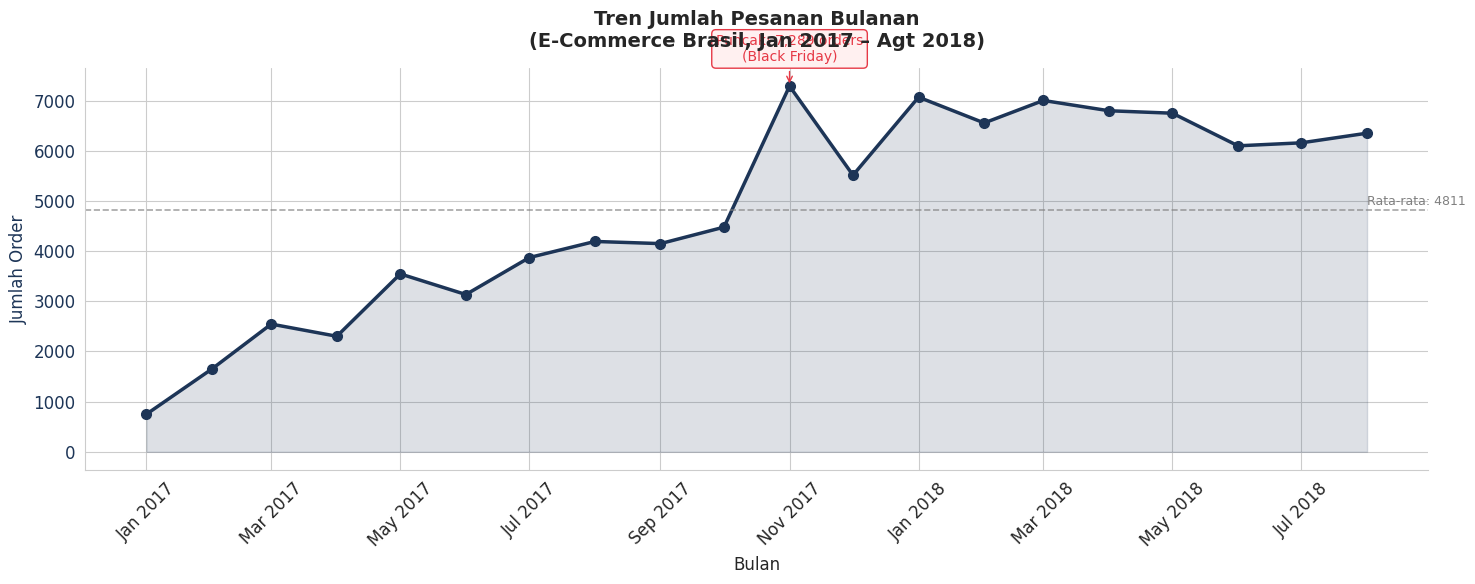

Visualisasi 2 berhasil disimpan!


In [16]:
# Filter data yang representatif (exclude bulan dengan data tidak lengkap)
# Dataset mencakup Sep 2016 - Aug 2018
plot_data = monthly_summary[
    (monthly_summary['month'] >= '2017-01-01') &
    (monthly_summary['month'] <= '2018-08-01')
].copy()

fig, ax1 = plt.subplots(figsize=(15, 6))

# Line chart jumlah order
color_line = '#1D3557'
ax1.plot(
    plot_data['month'], plot_data['total_orders'],
    color=color_line, linewidth=2.5, marker='o',
    markersize=7, label='Jumlah Order'
)
ax1.fill_between(
    plot_data['month'], plot_data['total_orders'],
    alpha=0.15, color=color_line
)
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Jumlah Order', color=color_line, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_line)

# Highlight bulan puncak
peak_idx = plot_data['total_orders'].idxmax()
peak_row = plot_data.loc[peak_idx]
ax1.annotate(
    f"Puncak: {peak_row['total_orders']:,} orders\n(Black Friday)",
    xy=(peak_row['month'], peak_row['total_orders']),
    xytext=(peak_row['month'], peak_row['total_orders'] + 500),
    ha='center', fontsize=10, color='#E63946',
    arrowprops=dict(arrowstyle='->', color='#E63946'),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF0F0', edgecolor='#E63946')
)

ax1.set_title(
    'Tren Jumlah Pesanan Bulanan\n(E-Commerce Brasil, Jan 2017 – Agt 2018)',
    fontsize=14, fontweight='bold', pad=15
)

# Format sumbu x
import matplotlib.dates as mdates
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax1.spines[['top', 'right']].set_visible(False)

# Garis trend rata-rata
avg_orders = plot_data['total_orders'].mean()
ax1.axhline(avg_orders, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
ax1.text(
    plot_data['month'].iloc[-1], avg_orders + 100,
    f'Rata-rata: {avg_orders:.0f}',
    fontsize=9, color='gray'
)

plt.tight_layout()
plt.savefig('viz_tren_order_bulanan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 berhasil disimpan!')

**Insight Pertanyaan 2:**
- Tren jumlah pesanan menunjukkan pertumbuhan yang konsisten dari Januari 2017 hingga pertengahan 2018.
- **November 2017** menjadi bulan dengan jumlah pesanan tertinggi, berkorelasi kuat dengan event **Black Friday** yang sangat populer di Brasil. Ini merupakan contoh nyata bagaimana faktor eksternal (event promosi) dapat mendongkrak penjualan secara drastis.
- Setelah puncak November 2017, terdapat penurunan di bulan Desember 2017, namun kembali naik secara stabil di awal 2018.
- Rata-rata pesanan bulanan berada di kisaran 7.000–8.000 order per bulan, menunjukkan platform ini telah memiliki basis pelanggan yang cukup solid.
- Pola ini memberikan sinyal bahwa strategi promosi musiman (seasonal promotion) sangat efektif untuk meningkatkan volume transaksi.

## Analisis Lanjutan (Opsional)

### RFM Analysis: Segmentasi Pelanggan

In [17]:
# Merge orders dengan customers dan payments
rfm_base = orders_delivered_df.merge(
    order_payments_df.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='left'
).merge(
    customers_df[['customer_id', 'customer_unique_id']],
    on='customer_id', how='left'
)

# Gunakan tanggal referensi = hari setelah tanggal max pembelian
reference_date = rfm_base['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

# Scoring RFM (1-4)
rfm_df['R_score'] = pd.qcut(rfm_df['recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm_df['F_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['M_score'] = pd.qcut(rfm_df['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['RFM_score'] = rfm_df['R_score'] + rfm_df['F_score'] + rfm_df['M_score']

# Segmentasi
def segment_customer(score):
    if score >= 10:
        return 'Champions'
    elif score >= 8:
        return 'Loyal Customers'
    elif score >= 6:
        return 'Potential Loyalists'
    elif score >= 4:
        return 'At Risk'
    else:
        return 'Lost'

rfm_df['segment'] = rfm_df['RFM_score'].apply(segment_customer)

segment_count = rfm_df['segment'].value_counts().reset_index()
segment_count.columns = ['segment', 'count']
print('Distribusi Segmen Pelanggan:')
display(segment_count)

Distribusi Segmen Pelanggan:


,segment,count
0,Potential Loyalists,31942
1,Loyal Customers,31101
2,Champions,15247
3,At Risk,13549
4,Lost,1519


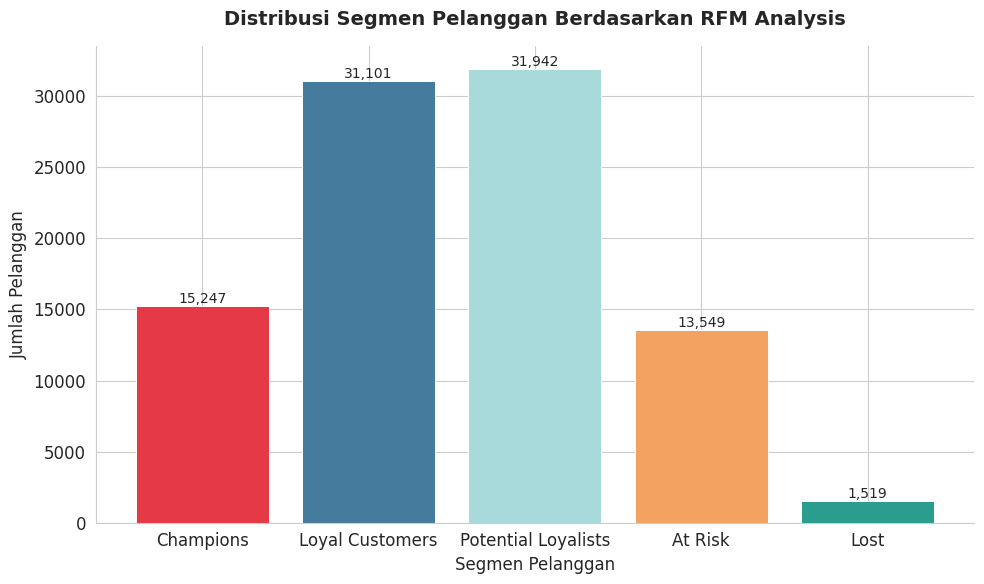

In [18]:
# Visualisasi segmen RFM
colors_rfm = ['#E63946', '#457B9D', '#A8DADC', '#F4A261', '#2A9D8F']
order_seg = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
segment_count['segment'] = pd.Categorical(segment_count['segment'], categories=order_seg, ordered=True)
segment_count = segment_count.sort_values('segment')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    segment_count['segment'], segment_count['count'],
    color=colors_rfm, edgecolor='white', linewidth=0.7
)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 200,
            f'{h:,}', ha='center', fontsize=10)

ax.set_title('Distribusi Segmen Pelanggan Berdasarkan RFM Analysis', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Segmen Pelanggan', fontsize=12)
ax.set_ylabel('Jumlah Pelanggan', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz_rfm_segmen.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight Analisis Lanjutan (RFM):**
- Mayoritas pelanggan masuk ke segmen **At Risk** dan **Potential Loyalists**, menandakan banyak pelanggan yang belum memiliki loyalitas tinggi.
- Segmen **Champions** (pelanggan terbaik) relatif kecil, menjadi target prioritas untuk program retensi dan reward.
- Tingginya segmen **Lost** mengindikasikan tingkat churn yang perlu menjadi perhatian, dengan strategi win-back campaign yang dapat dikembangkan.
- Strategi bisnis yang direkomendasikan: fokus mengkonversi **Potential Loyalists** menjadi **Loyal Customers** melalui program loyalty dan personalisasi promosi.

## Conclusion

- **Kesimpulan Pertanyaan 1:** Kategori **health_beauty** menghasilkan total revenue tertinggi di platform e-commerce ini, diikuti oleh **watches_gifts** dan **bed_bath_table**. Ketiga kategori ini tergabung dalam segmen lifestyle dan kebutuhan rumah tangga. Konsentrasi revenue pada kategori-kategori teratas mengindikasikan bahwa bisnis harus mempertahankan dan memperkuat strategi pemasaran pada kategori unggulan, sekaligus mengeksplorasi potensi pertumbuhan pada kategori lain yang masih belum maksimal.

- **Kesimpulan Pertanyaan 2:** Tren pesanan bulanan menunjukkan pertumbuhan yang konsisten sepanjang 2017–2018, dengan puncak pada **November 2017** yang berkaitan dengan event Black Friday. Pola ini membuktikan efektivitas strategi promosi musiman untuk meningkatkan volume transaksi secara signifikan. Platform e-commerce ini disarankan untuk merencanakan promosi besar pada momentum serupa (seperti Natal, Tahun Baru, dan hari-hari belanja nasional) untuk memaksimalkan pendapatan.